# Machine Learning-Based Phishing Website Detection

## Course Capstone Project

### Objective
The goal of this project is to develop a machine learning model that can classify websites as phishing or legitimate based on website characteristics.

### Dataset
The project uses the UCI Phishing Websites Dataset, which contains website-related features used for binary classification.

### Methodology
This project follows the CRISP-DM framework:
- Business Understanding
- Data Understanding
- Data Preparation
- Modeling
- Evaluation
- Insights

In [27]:
#Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
#Load the dataset

df = pd.read_csv("csv_result-Training Dataset.csv")

df.head()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [10]:
#explore the dataset

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())



Dataset shape: (11055, 32)

Column names:
['id', 'having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']

Missing values:
id                             0
having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token       

In [12]:
#visualize class distribution

# Identify target column (last column)

target_column = df.columns[-1]

# Display class counts

print(df[target_column].value_counts())

Result
 1    6157
-1    4898
Name: count, dtype: int64


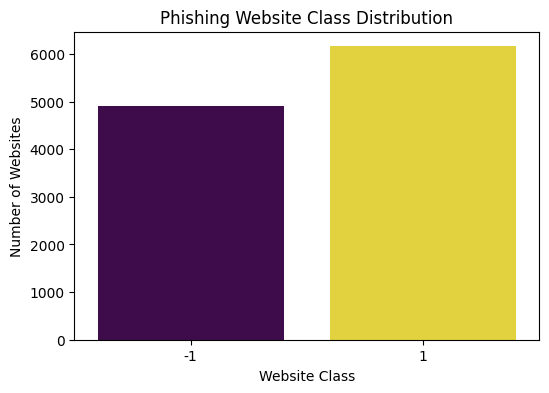

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x=target_column,
    hue=target_column,
    palette="viridis",
    legend=False
)

plt.title("Phishing Website Class Distribution")

plt.xlabel("Website Class")

plt.ylabel("Number of Websites")

plt.show()

In [18]:
#define features and target

X = df.drop(df.columns[-1], axis=1)

y = df[df.columns[-1]]


# Check the shape of features and target

print("Features shape:", X.shape)

print("Target shape:", y.shape)

Features shape: (11055, 31)
Target shape: (11055,)


In [19]:
#split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set shape: (8844, 31)
Testing set shape: (2211, 31)

Training class distribution:
Result
 1    4926
-1    3918
Name: count, dtype: int64

Testing class distribution:
Result
 1    1231
-1     980
Name: count, dtype: int64


In [20]:
#scale the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (8844, 31)
Scaled testing data shape: (2211, 31)


In [22]:
#compile the model

deep_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [28]:
# Train Model

model_1 = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_1.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [29]:
#Evaluate model 1

y_pred_1 = model_1.predict(X_test_scaled)

accuracy_1 = accuracy_score(y_test, y_pred_1)
precision_1 = precision_score(y_test, y_pred_1, zero_division=0)
recall_1 = recall_score(y_test, y_pred_1, zero_division=0)
f1_1 = f1_score(y_test, y_pred_1, zero_division=0)

print("Model 1 Accuracy:", accuracy_1)
print("Model 1 Precision:", precision_1)
print("Model 1 Recall:", recall_1)
print("Model 1 F1 Score:", f1_1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_1, zero_division=0))

Model 1 Accuracy: 0.9289914066033469
Model 1 Precision: 0.9337641357027464
Model 1 Recall: 0.9390739236393176
Model 1 F1 Score: 0.9364115026326448

Classification Report:
              precision    recall  f1-score   support

          -1       0.92      0.92      0.92       980
           1       0.93      0.94      0.94      1231

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



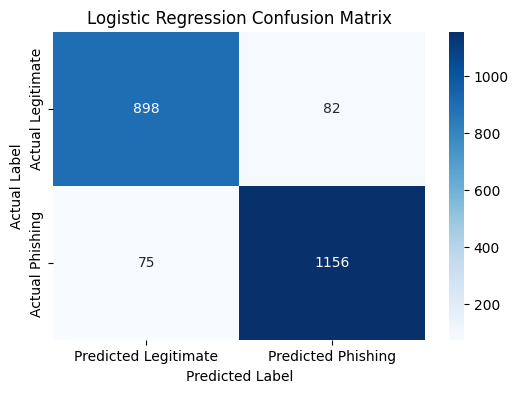

In [31]:
# Model 1 Confusion Matrix

cm_1 = confusion_matrix(
    y_test,
    y_pred_1
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legitimate", "Predicted Phishing"],
    yticklabels=["Actual Legitimate", "Actual Phishing"]
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

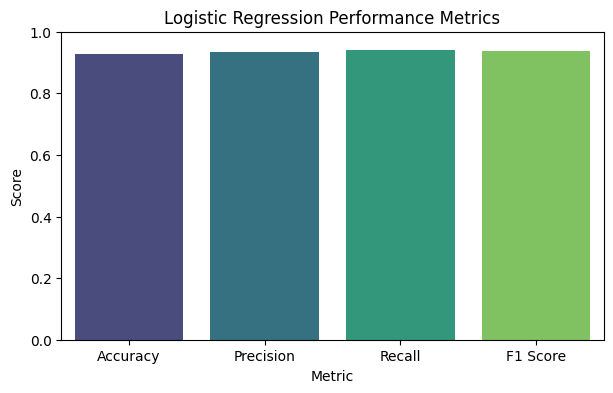

In [33]:
# Model Performance Metrics Visualization

metrics = {
    "Accuracy": accuracy_1,
    "Precision": precision_1,
    "Recall": recall_1,
    "F1 Score": f1_1
}


metrics_df = pd.DataFrame(
    list(metrics.items()),
    columns=["Metric", "Score"]
)


plt.figure(figsize=(7,4))

sns.barplot(
    data=metrics_df,
    x="Metric",
    y="Score",
    hue="Metric",
    palette="viridis",
    legend=False
)


plt.title("Logistic Regression Performance Metrics")

plt.ylabel("Score")

plt.ylim(0,1)

plt.show()

# Interpretation of Findings

## Model Performance Analysis

The Logistic Regression model achieved strong performance on the phishing website classification task.

The model achieved:
- Accuracy: 92.9%
- Precision: 93.4%
- Recall: 93.9%
- F1 Score: 93.6%

These results show that the model was able to successfully identify patterns associated with phishing websites.

## Cybersecurity Insights

The analysis demonstrates that website characteristics can be used to detect potentially malicious websites.

Features related to URL structure, website security indicators, and other webpage attributes provide useful information for classification.

The high recall score is especially important in cybersecurity because it indicates that the model was effective at identifying phishing websites and reducing missed threats.

## Errors and Limitations

The confusion matrix shows that some websites were incorrectly classified.

False positives occur when legitimate websites are classified as phishing, which may affect user experience.

False negatives occur when phishing websites are classified as legitimate, which represents a larger security concern.

## Future Improvements

The model could be improved by:
- Testing additional machine learning algorithms
- Applying hyperparameter tuning
- Using larger and newer phishing datasets
- Creating a real-time detection system